### 二

In [1]:
import os
import time
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
start_time = time.time()
# 定义注意力模块
class AttentionModule(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(AttentionModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# 定义带有注意力机制的ResNet-18模型
class ResNetWithAttention(nn.Module):
    def __init__(self, num_classes):
        super(ResNetWithAttention, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.attention = AttentionModule(512)  # 注意力模块应用在ResNet-18的最后一个卷积层输出上
        self.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.attention(x)
        
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# 数据预处理和加载
# data_transforms0 = {
#     'train': transforms.Compose([
#         transforms.Resize(256),
#         transforms.RandomResizedCrop(224),
#         transforms.RandomHorizontalFlip(),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ]),
#     'val': transforms.Compose([
#         transforms.Resize(256),
#         transforms.CenterCrop(224),
#         transforms.ToTensor(),
#         transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
#     ])
# }

# # 加载数据集
# data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
# image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms0[x]) for x in ['train', 'val']}
# train_loader = DataLoader(image_datasets['train'], batch_size=64, shuffle=True, num_workers=4)
# val_loader = DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)
# 创建ResNet-18模型实例
num_classes = 4  # 类别数为10（CIFAR-10数据集）
model = ResNetWithAttention(num_classes)

# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

# 定义微调训练函数
def fine_tune(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    
    best_acc = 0.0
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        train_loss = 0.0
        train_correct = 0
        
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            train_correct += (predicted == labels).sum().item()
            train_loss += loss.item() * images.size(0)
        
        train_accuracy = 100.0 * train_correct / len(train_loader.dataset)
        train_loss = train_loss / len(train_loader.dataset)
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_correct = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                _, predicted = torch.max(outputs.data, 1)
                val_correct += (predicted == labels).sum().item()
                val_loss += loss.item() * images.size(0)
        val_accuracy = 100.0 * val_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        
        # 打印训练结果
        print("Epoch [{}/{}], Train Loss: {:.4f}, Train Acc: {:.2f}%, Val Loss: {:.4f}, Val Acc: {:.2f}%"
              .format(epoch+1, num_epochs, train_loss, train_accuracy, val_loss, val_accuracy))
#         with open(result_file, "a") as file:
#             file.write("Epoch [{}/{}], Train Loss: {:.4f}, Train Acc: {:.2f}%, Val Loss: {:.4f}, Val Acc: {:.2f}%\n"
#               .format(epoch+1, num_epochs, train_loss, train_accuracy, val_loss, val_accuracy))
        
        # 保存最佳模型
        if val_accuracy > best_acc:
            best_acc = val_accuracy
            torch.save(model.state_dict(), "best_model.pth")
    
    print("Training complete!")
    print("Best validation accuracy: {:.2f}%".format(best_acc))

# 使用微调训练函数进行微调训练
num_epochs = 100  # 根据需要进行调整
fine_tune(model, train_loader, val_loader, criterion, optimizer, num_epochs)
end_time = time.time()
# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

Epoch [1/100], Train Loss: 1.3785, Train Acc: 28.29%, Val Loss: 1.3370, Val Acc: 38.74%
Epoch [2/100], Train Loss: 1.2227, Train Acc: 53.49%, Val Loss: 1.2297, Val Acc: 47.75%
Epoch [3/100], Train Loss: 1.0394, Train Acc: 75.78%, Val Loss: 1.0998, Val Acc: 61.71%
Epoch [4/100], Train Loss: 0.8455, Train Acc: 86.05%, Val Loss: 0.9123, Val Acc: 76.13%
Epoch [5/100], Train Loss: 0.7174, Train Acc: 86.24%, Val Loss: 0.7768, Val Acc: 78.83%
Epoch [6/100], Train Loss: 0.5869, Train Acc: 91.67%, Val Loss: 0.6200, Val Acc: 88.74%
Epoch [7/100], Train Loss: 0.4781, Train Acc: 93.02%, Val Loss: 0.5272, Val Acc: 90.99%
Epoch [8/100], Train Loss: 0.4151, Train Acc: 94.96%, Val Loss: 0.4720, Val Acc: 91.44%
Epoch [9/100], Train Loss: 0.3385, Train Acc: 97.29%, Val Loss: 0.4213, Val Acc: 91.44%
Epoch [10/100], Train Loss: 0.2848, Train Acc: 97.87%, Val Loss: 0.3830, Val Acc: 90.09%
Epoch [11/100], Train Loss: 0.2402, Train Acc: 97.87%, Val Loss: 0.2995, Val Acc: 93.69%
Epoch [12/100], Train Loss: 0.

Epoch [93/100], Train Loss: 0.0105, Train Acc: 100.00%, Val Loss: 0.0583, Val Acc: 97.75%
Epoch [94/100], Train Loss: 0.0095, Train Acc: 100.00%, Val Loss: 0.0525, Val Acc: 97.75%
Epoch [95/100], Train Loss: 0.0335, Train Acc: 99.42%, Val Loss: 0.0572, Val Acc: 97.30%
Epoch [96/100], Train Loss: 0.0135, Train Acc: 99.61%, Val Loss: 0.1635, Val Acc: 95.05%
Epoch [97/100], Train Loss: 0.0210, Train Acc: 99.81%, Val Loss: 0.1516, Val Acc: 94.14%
Epoch [98/100], Train Loss: 0.0278, Train Acc: 99.22%, Val Loss: 0.2228, Val Acc: 92.79%
Epoch [99/100], Train Loss: 0.0325, Train Acc: 99.42%, Val Loss: 0.1198, Val Acc: 94.59%
Epoch [100/100], Train Loss: 0.0293, Train Acc: 99.03%, Val Loss: 0.0980, Val Acc: 94.59%
Training complete!
Best validation accuracy: 98.20%
361.18285155296326


In [3]:
import os
import time
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch.autograd import Variable
start_time = time.time()
# 定义注意力模块
class AttentionModule(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(AttentionModule, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction_ratio, in_channels),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# 定义带有注意力机制的ResNet-18模型
class ResNetWithAttention(nn.Module):
    def __init__(self, num_classes):
        super(ResNetWithAttention, self).__init__()
        self.resnet = models.resnet18(pretrained=True)
        self.attention = AttentionModule(512)  # 注意力模块应用在ResNet-18的最后一个卷积层输出上
        self.fc = nn.Linear(512, num_classes)
    
    def forward(self, x):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)

        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)

        x = self.attention(x)
        
        x = self.resnet.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

num_classes = 4  # 类别数为10（CIFAR-10数据集）
model = ResNetWithAttention(num_classes)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

predictions = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu()) 
        break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(predictions))

AttributeError: 'ResNetWithAttention' object has no attribute 'svm'

In [2]:
# 导入所需的库
import numpy as np

predictions = np.array(predictions)
labels = np.array(labels.cpu())
# 计算准确率
accuracy = np.mean(labels == predictions) * 100
print("Test Accuracy: {:.2f}%".format(accuracy))

Test Accuracy: 85.94%


[[16  1  1  5]
 [ 2 10  0  0]
 [ 0  0 11  0]
 [ 0  0  0 18]]
Normalized confusion matrix
[[0.69565217 0.04347826 0.04347826 0.2173913 ]
 [0.16666667 0.83333333 0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.         0.         0.         1.        ]]


<ipython-input-3-5c5902fcdf15>:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


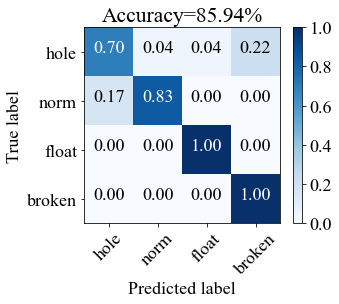

In [3]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('attention_rsvm_con.png', dpi=300)
    plt.tight_layout()
    
cnf_matrix = confusion_matrix(labels,predictions)
print(cnf_matrix)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels,predictions)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)